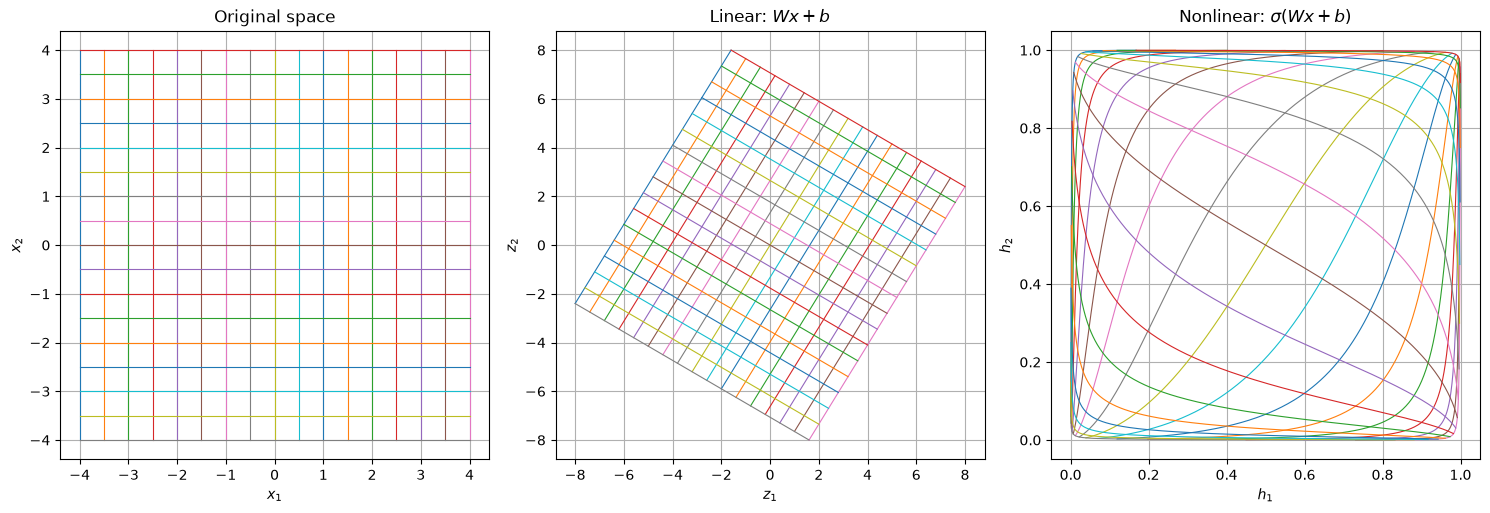

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# Linear transformation
W = np.array([
    [1.2,  0.8],
    [-0.7, 1.3]
])

b = np.array([0.0, 0.0])


def linear_transform(points):
    return points @ W.T + b


def sigmoid_transform(points):
    z = linear_transform(points)
    return sigmoid(z)


# --------------------------------------------------
# Grid 생성
# --------------------------------------------------

grid_range = np.linspace(-4, 4, 400)
grid_lines = np.linspace(-4, 4, 17)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ==================================================
# 1. Original space
# ==================================================

for x in grid_lines:
    points = np.column_stack([
        np.full_like(grid_range, x),
        grid_range
    ])

    axes[0].plot(points[:, 0], points[:, 1], linewidth=0.8)


for y in grid_lines:
    points = np.column_stack([
        grid_range,
        np.full_like(grid_range, y)
    ])

    axes[0].plot(points[:, 0], points[:, 1], linewidth=0.8)


axes[0].set_title("Original space")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_aspect("equal")
axes[0].grid(True)


# ==================================================
# 2. Linear transformation: Wx + b
# ==================================================

for x in grid_lines:
    points = np.column_stack([
        np.full_like(grid_range, x),
        grid_range
    ])

    transformed = linear_transform(points)

    axes[1].plot(
        transformed[:, 0],
        transformed[:, 1],
        linewidth=0.8
    )


for y in grid_lines:
    points = np.column_stack([
        grid_range,
        np.full_like(grid_range, y)
    ])

    transformed = linear_transform(points)

    axes[1].plot(
        transformed[:, 0],
        transformed[:, 1],
        linewidth=0.8
    )


axes[1].set_title(r"Linear: $Wx+b$")
axes[1].set_xlabel("$z_1$")
axes[1].set_ylabel("$z_2$")
axes[1].set_aspect("equal")
axes[1].grid(True)


# ==================================================
# 3. Nonlinear transformation: sigmoid(Wx+b)
# ==================================================

for x in grid_lines:
    points = np.column_stack([
        np.full_like(grid_range, x),
        grid_range
    ])

    transformed = sigmoid_transform(points)

    axes[2].plot(
        transformed[:, 0],
        transformed[:, 1],
        linewidth=0.8
    )


for y in grid_lines:
    points = np.column_stack([
        grid_range,
        np.full_like(grid_range, y)
    ])

    transformed = sigmoid_transform(points)

    axes[2].plot(
        transformed[:, 0],
        transformed[:, 1],
        linewidth=0.8
    )


axes[2].set_title(r"Nonlinear: $\sigma(Wx+b)$")
axes[2].set_xlabel("$h_1$")
axes[2].set_ylabel("$h_2$")
axes[2].set_xlim(-0.05, 1.05)
axes[2].set_ylim(-0.05, 1.05)
axes[2].set_aspect("equal")
axes[2].grid(True)


plt.tight_layout()
plt.show()

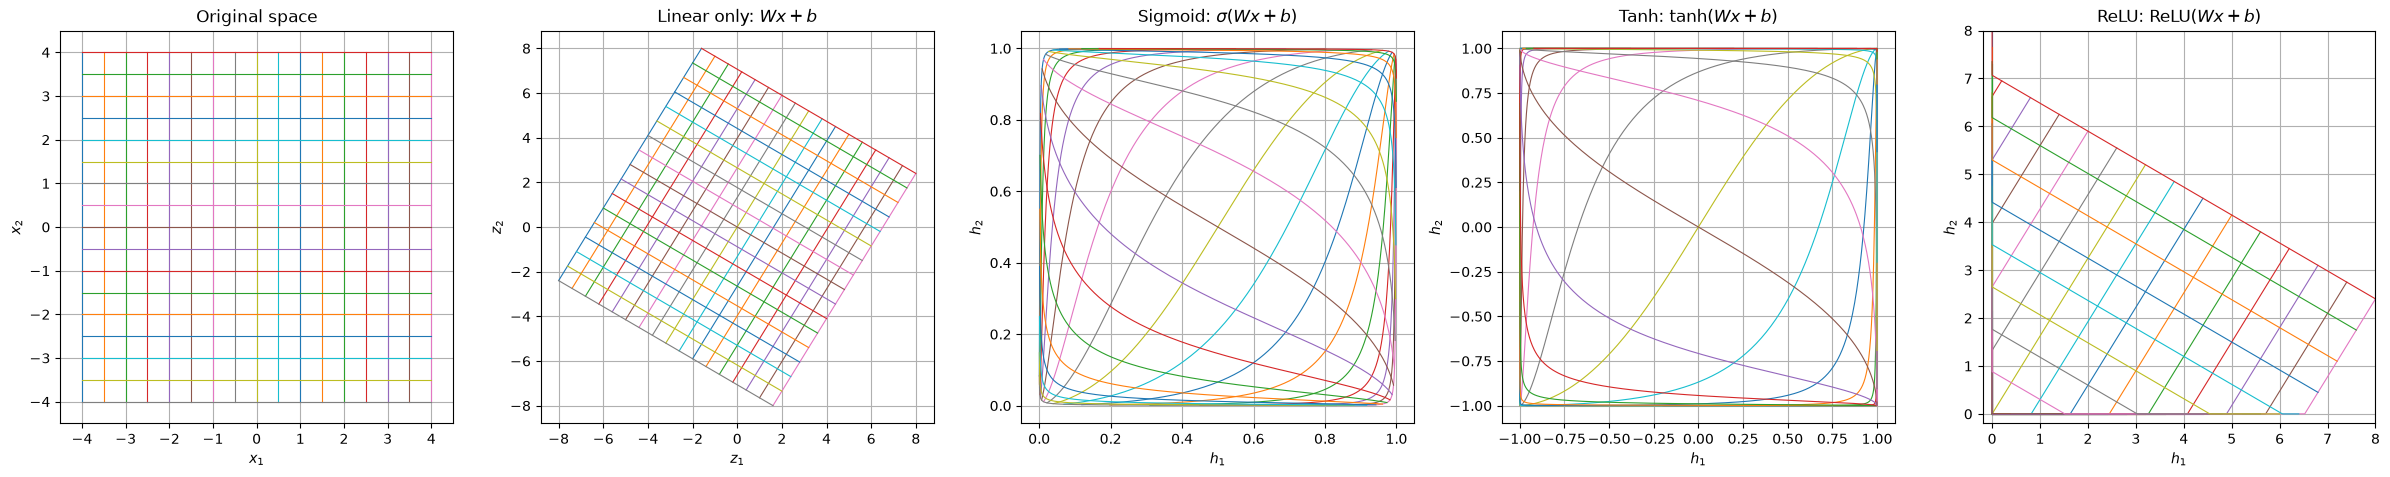

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# 1. Activation functions
# =========================================================
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def relu(x):
    return np.maximum(0, x)


# =========================================================
# 2. Linear transform
#    같은 선형변환 뒤에 activation만 바꿔서 비교
# =========================================================
W = np.array([
    [1.2,  0.8],
    [-0.7, 1.3]
], dtype=float)

b = np.array([0.0, 0.0], dtype=float)


def linear_transform(points):
    return points @ W.T + b


def nonlinear_transform(points, activation_fn):
    z = linear_transform(points)
    return activation_fn(z)


# =========================================================
# 3. Grid 만들기
# =========================================================
grid_range = np.linspace(-4, 4, 400)
grid_lines = np.linspace(-4, 4, 17)


def make_vertical_line(x_const):
    return np.column_stack([
        np.full_like(grid_range, x_const),
        grid_range
    ])


def make_horizontal_line(y_const):
    return np.column_stack([
        grid_range,
        np.full_like(grid_range, y_const)
    ])


# =========================================================
# 4. Plot helper
# =========================================================
def draw_grid(ax, transform_fn=None, title=""):
    for x in grid_lines:
        pts = make_vertical_line(x)
        if transform_fn is not None:
            pts = transform_fn(pts)
        ax.plot(pts[:, 0], pts[:, 1], linewidth=0.8)

    for y in grid_lines:
        pts = make_horizontal_line(y)
        if transform_fn is not None:
            pts = transform_fn(pts)
        ax.plot(pts[:, 0], pts[:, 1], linewidth=0.8)

    ax.set_title(title)
    ax.grid(True)
    ax.set_aspect("equal")


# =========================================================
# 5. Draw
# =========================================================
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

# (1) Original space
draw_grid(
    axes[0],
    transform_fn=None,
    title="Original space"
)
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_xlim(-4.5, 4.5)
axes[0].set_ylim(-4.5, 4.5)

# (2) Linear only
draw_grid(
    axes[1],
    transform_fn=linear_transform,
    title=r"Linear only: $Wx+b$"
)
axes[1].set_xlabel("$z_1$")
axes[1].set_ylabel("$z_2$")

# (3) Sigmoid
draw_grid(
    axes[2],
    transform_fn=lambda p: nonlinear_transform(p, sigmoid),
    title=r"Sigmoid: $\sigma(Wx+b)$"
)
axes[2].set_xlabel("$h_1$")
axes[2].set_ylabel("$h_2$")
axes[2].set_xlim(-0.05, 1.05)
axes[2].set_ylim(-0.05, 1.05)

# (4) tanh
draw_grid(
    axes[3],
    transform_fn=lambda p: nonlinear_transform(p, tanh),
    title=r"Tanh: $\tanh(Wx+b)$"
)
axes[3].set_xlabel("$h_1$")
axes[3].set_ylabel("$h_2$")
axes[3].set_xlim(-1.1, 1.1)
axes[3].set_ylim(-1.1, 1.1)

# (5) ReLU
draw_grid(
    axes[4],
    transform_fn=lambda p: nonlinear_transform(p, relu),
    title=r"ReLU: $\mathrm{ReLU}(Wx+b)$"
)
axes[4].set_xlabel("$h_1$")
axes[4].set_ylabel("$h_2$")
axes[4].set_xlim(-0.2, 8)
axes[4].set_ylim(-0.2, 8)

plt.tight_layout()
plt.show()

device: cpu
Epoch 1/5, loss = 0.5817
Epoch 2/5, loss = 0.1411
Epoch 3/5, loss = 0.0921
Epoch 4/5, loss = 0.0735
Epoch 5/5, loss = 0.0631
Accuracy = 98.21%
True label: 7
Prediction: 7


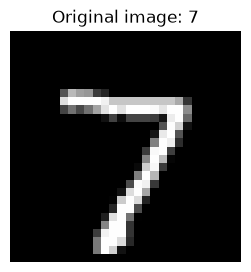

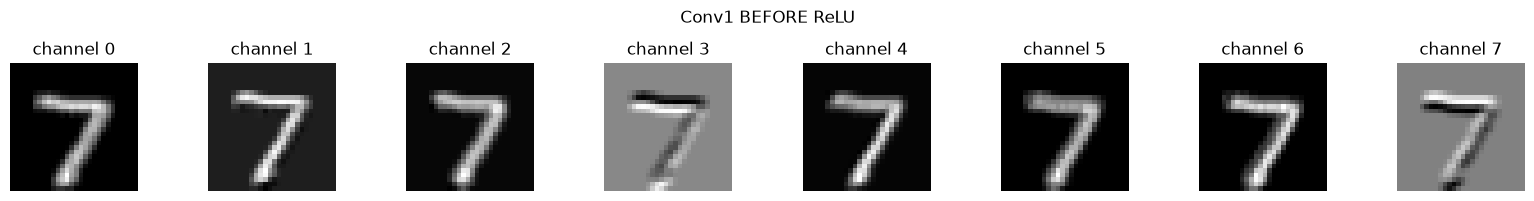

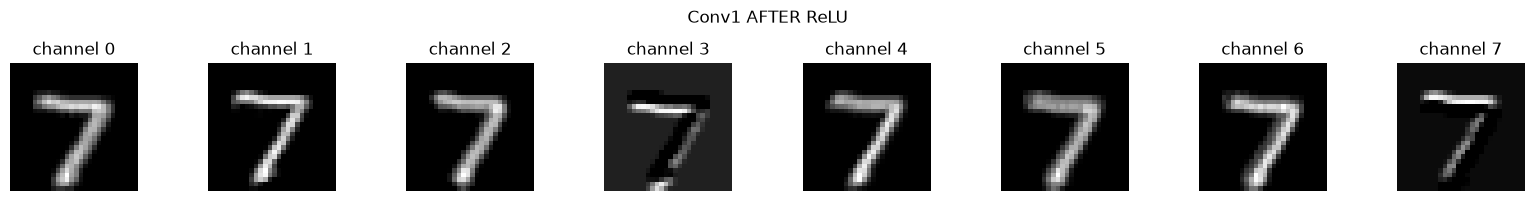

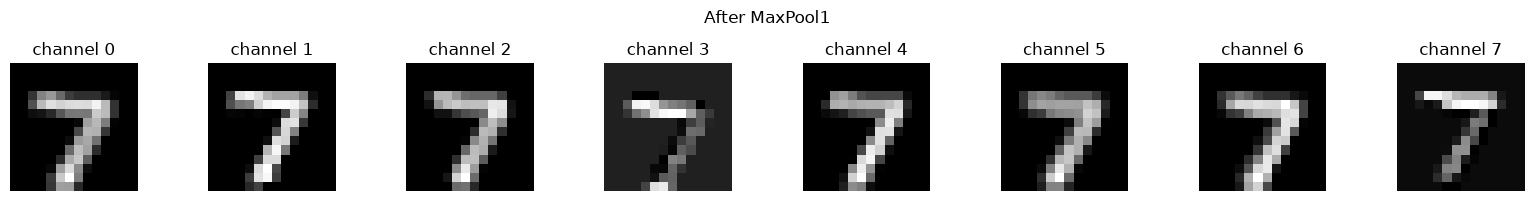

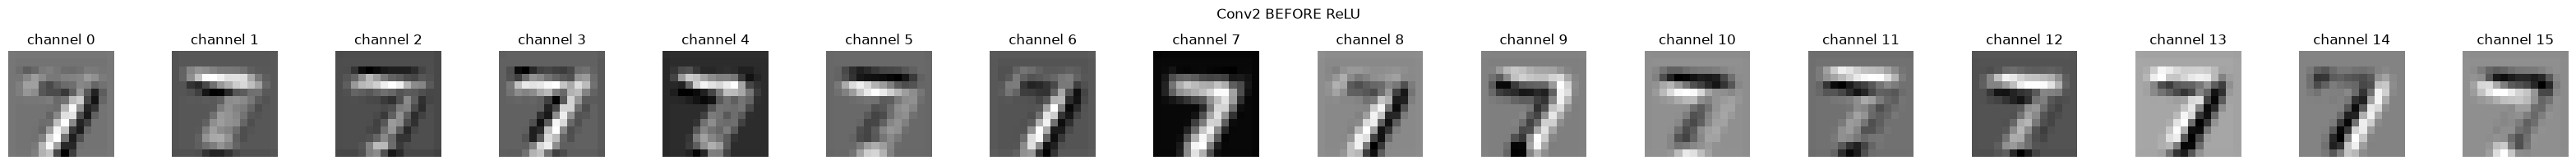

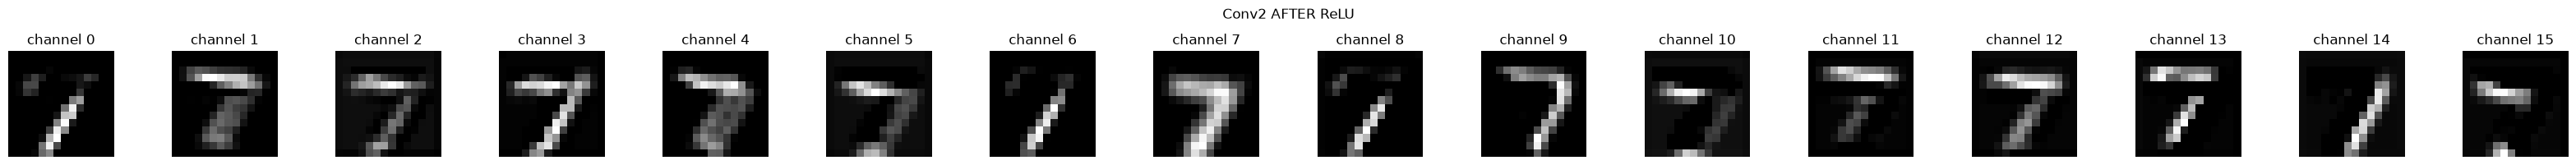

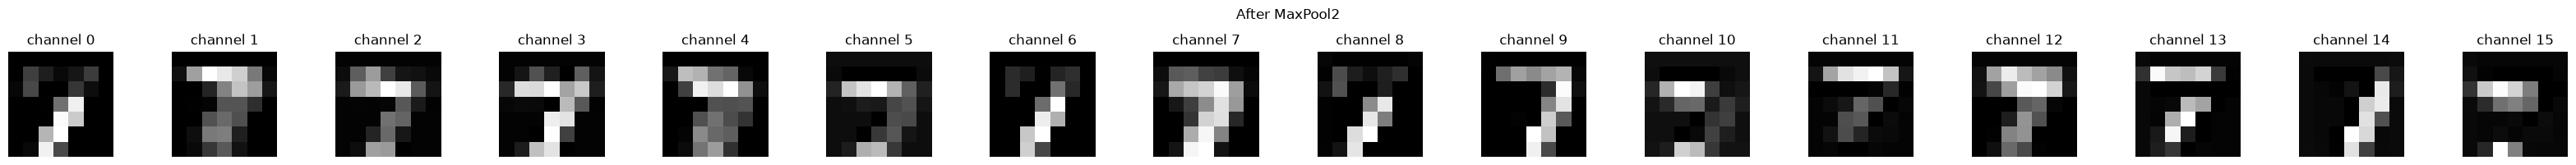

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA


# ============================================================
# 1. MNIST
# ============================================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("device:", device)


# ============================================================
# 2. CNN
# ============================================================

class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        # 28 x 28
        self.conv1 = nn.Conv2d(
            1,
            8,
            kernel_size=3,
            padding=1
        )

        # 14 x 14
        self.conv2 = nn.Conv2d(
            8,
            16,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(2)

        # 16 x 7 x 7 = 784
        self.fc1 = nn.Linear(
            16 * 7 * 7,
            64
        )

        self.fc2 = nn.Linear(
            64,
            10
        )

    def forward(
        self,
        x,
        return_features=False
    ):

        # ----------------------------------
        # CNN block 1
        # ----------------------------------

        z1 = self.conv1(x)        # linear convolution

        a1 = self.relu(z1)        # nonlinear transformation

        p1 = self.pool(a1)


        # ----------------------------------
        # CNN block 2
        # ----------------------------------

        z2 = self.conv2(p1)

        a2 = self.relu(z2)

        p2 = self.pool(a2)


        # ----------------------------------
        # Fully connected representation
        # ----------------------------------

        flat = p2.flatten(1)

        z3 = self.fc1(flat)

        h = self.relu(z3)

        logits = self.fc2(h)


        if return_features:

            return {
                "logits": logits,

                "conv1": z1,
                "relu1": a1,
                "pool1": p1,

                "conv2": z2,
                "relu2": a2,
                "pool2": p2,

                "hidden": h
            }

        return logits


model = CNN().to(device)


# ============================================================
# 3. Train
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)

epochs = 5


for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"loss = {total_loss / len(train_loader):.4f}"
    )


# ============================================================
# 4. Test accuracy
# ============================================================

model.eval()

correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        pred = logits.argmax(1)

        correct += (
            pred == labels
        ).sum().item()

        total += labels.size(0)


print(
    f"Accuracy = "
    f"{100 * correct / total:.2f}%"
)


# ============================================================
# 5. 하나의 이미지가 CNN을 통과하는 모습
# ============================================================

image, label = test_dataset[0]

x = image.unsqueeze(0).to(device)


with torch.no_grad():

    features = model(
        x,
        return_features=True
    )


print("True label:", label)

print(
    "Prediction:",
    features["logits"].argmax(1).item()
)


# ============================================================
# 6. Feature map plotting 함수
# ============================================================

def plot_feature_maps(
    tensor,
    title,
    max_maps=8
):

    tensor = (
        tensor
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
    )

    n_maps = min(
        tensor.shape[0],
        max_maps
    )

    fig, axes = plt.subplots(
        1,
        n_maps,
        figsize=(2 * n_maps, 2)
    )

    if n_maps == 1:
        axes = [axes]


    for i in range(n_maps):

        axes[i].imshow(
            tensor[i],
            cmap="gray"
        )

        axes[i].set_title(
            f"channel {i}"
        )

        axes[i].axis("off")


    fig.suptitle(title)

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. Original image
# ============================================================

plt.figure(figsize=(3, 3))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Original image: {label}"
)

plt.axis("off")

plt.show()


# ============================================================
# 8. CNN 내부 공간 변화
# ============================================================

plot_feature_maps(
    features["conv1"],
    "Conv1 BEFORE ReLU"
)

plot_feature_maps(
    features["relu1"],
    "Conv1 AFTER ReLU"
)

plot_feature_maps(
    features["pool1"],
    "After MaxPool1"
)

plot_feature_maps(
    features["conv2"],
    "Conv2 BEFORE ReLU",
    max_maps=16
)

plot_feature_maps(
    features["relu2"],
    "Conv2 AFTER ReLU",
    max_maps=16
)

plot_feature_maps(
    features["pool2"],
    "After MaxPool2",
    max_maps=16
)

Device: cpu
Epoch  1/10, Loss = 2.2481
Epoch  2/10, Loss = 0.8493
Epoch  3/10, Loss = 0.4343
Epoch  4/10, Loss = 0.3387
Epoch  5/10, Loss = 0.2850
Epoch  6/10, Loss = 0.2459
Epoch  7/10, Loss = 0.2143
Epoch  8/10, Loss = 0.1893
Epoch  9/10, Loss = 0.1710
Epoch 10/10, Loss = 0.1552
Test Accuracy: 95.70%
True: 7 Prediction: 7


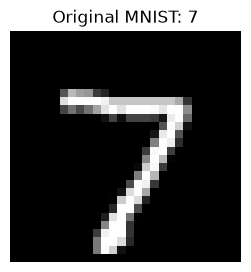

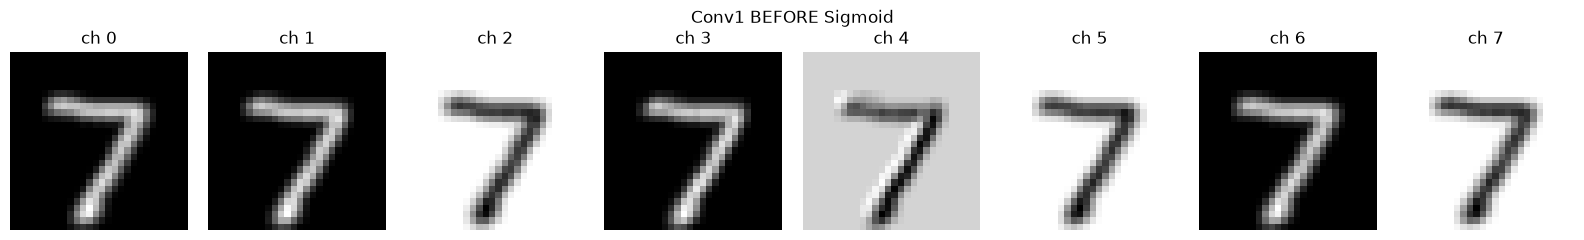

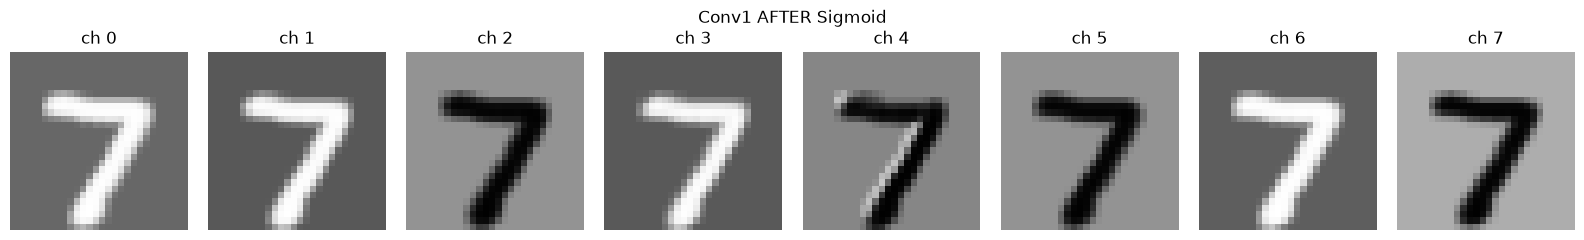

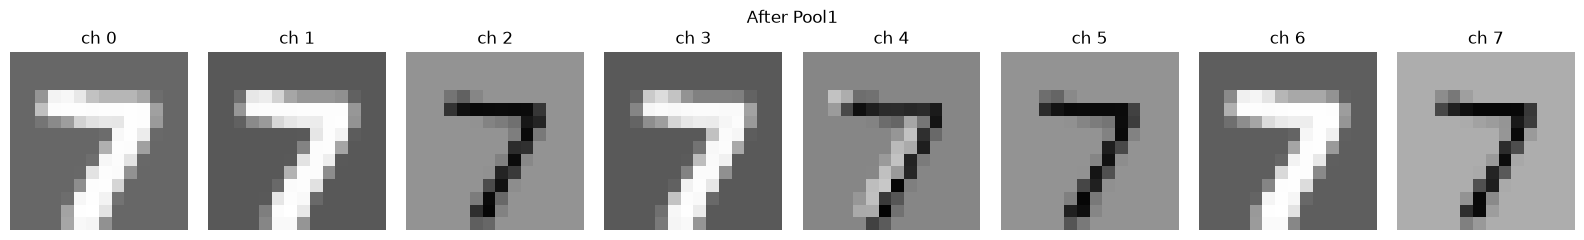

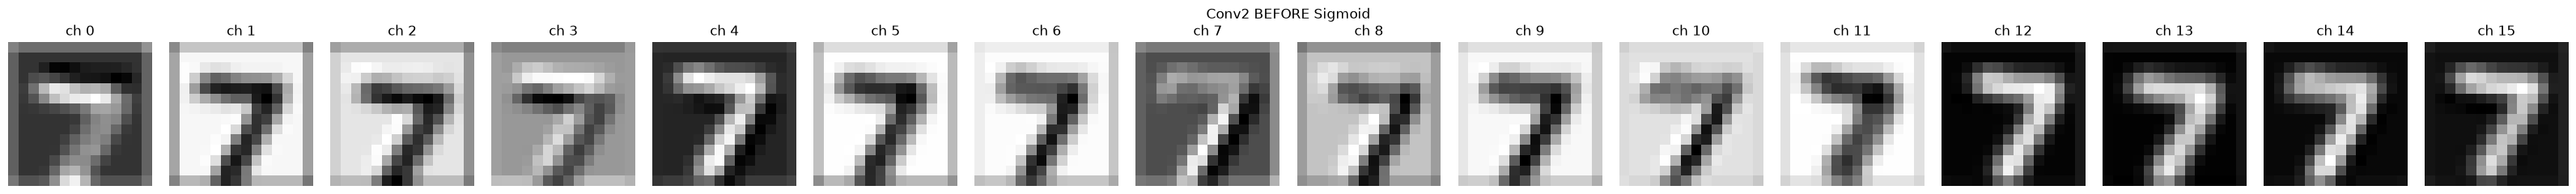

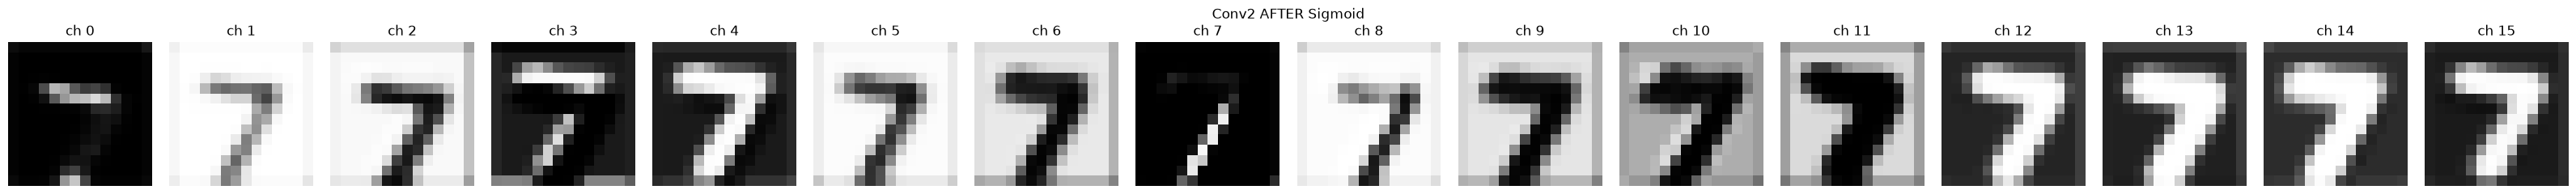

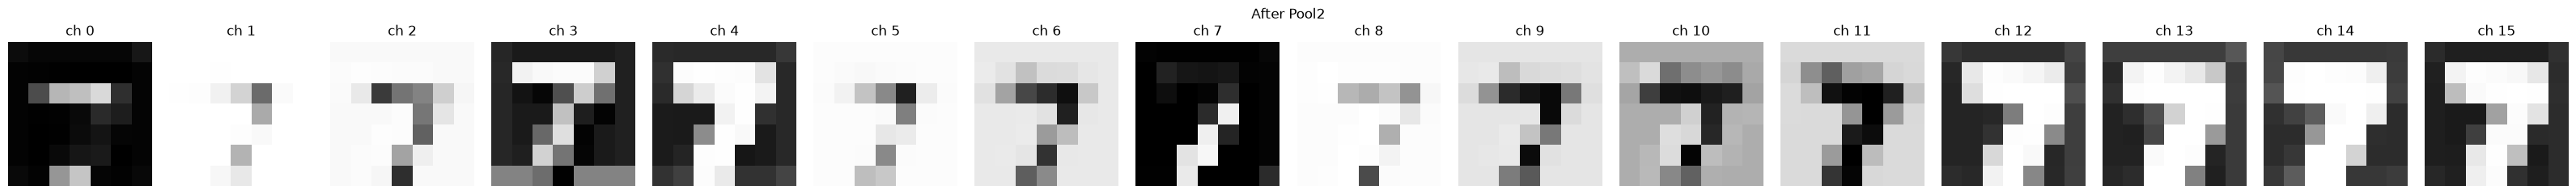

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

from sklearn.decomposition import PCA


# ============================================================
# 1. MNIST
# ============================================================

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)


# ============================================================
# 2. CNN + Sigmoid
# ============================================================

class SigmoidCNN(nn.Module):

    def __init__(self):
        super().__init__()

        # 28 x 28 -> 28 x 28
        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=8,
            kernel_size=3,
            padding=1
        )

        # 14 x 14 -> 14 x 14
        self.conv2 = nn.Conv2d(
            in_channels=8,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(
            16 * 7 * 7,
            64
        )

        self.fc2 = nn.Linear(
            64,
            10
        )

        self.sigmoid = nn.Sigmoid()


    def forward(self, x, return_features=False):

        # ====================================================
        # Block 1
        # ====================================================

        z1 = self.conv1(x)

        # 비선형 공간 변환
        a1 = self.sigmoid(z1)

        p1 = self.pool(a1)


        # ====================================================
        # Block 2
        # ====================================================

        z2 = self.conv2(p1)

        a2 = self.sigmoid(z2)

        p2 = self.pool(a2)


        # ====================================================
        # Fully connected
        # ====================================================

        flat = p2.flatten(1)

        z3 = self.fc1(flat)

        h = self.sigmoid(z3)

        logits = self.fc2(h)


        if return_features:

            return {
                "logits": logits,

                "conv1_before": z1,
                "conv1_after": a1,
                "pool1": p1,

                "conv2_before": z2,
                "conv2_after": a2,
                "pool2": p2,

                "fc_before": z3,
                "hidden": h
            }

        return logits


model = SigmoidCNN().to(device)


# ============================================================
# 3. Train
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

epochs = 10


for epoch in range(epochs):

    model.train()

    total_loss = 0.0


    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    print(
        f"Epoch {epoch + 1:2d}/{epochs}, "
        f"Loss = {total_loss / len(train_loader):.4f}"
    )


# ============================================================
# 4. Accuracy
# ============================================================

model.eval()

correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        prediction = logits.argmax(dim=1)

        correct += (
            prediction == labels
        ).sum().item()

        total += labels.size(0)


print(
    f"Test Accuracy: "
    f"{100 * correct / total:.2f}%"
)


# ============================================================
# 5. Feature map 하나 확인
# ============================================================

image, label = test_dataset[0]

x = image.unsqueeze(0).to(device)


with torch.no_grad():

    features = model(
        x,
        return_features=True
    )


prediction = (
    features["logits"]
    .argmax(dim=1)
    .item()
)

print(
    "True:",
    label,
    "Prediction:",
    prediction
)


# ============================================================
# 6. Feature map 그리기
# ============================================================

def plot_feature_maps(
    tensor,
    title,
    max_maps=8,
    vmin=None,
    vmax=None
):

    data = (
        tensor
        .squeeze(0)
        .detach()
        .cpu()
        .numpy()
    )

    n_maps = min(
        data.shape[0],
        max_maps
    )


    fig, axes = plt.subplots(
        1,
        n_maps,
        figsize=(2 * n_maps, 2.4)
    )


    if n_maps == 1:
        axes = [axes]


    for i in range(n_maps):

        axes[i].imshow(
            data[i],
            cmap="gray",
            vmin=vmin,
            vmax=vmax
        )

        axes[i].set_title(
            f"ch {i}"
        )

        axes[i].axis("off")


    fig.suptitle(title)

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. Original
# ============================================================

plt.figure(figsize=(3, 3))

plt.imshow(
    image.squeeze(),
    cmap="gray"
)

plt.title(
    f"Original MNIST: {label}"
)

plt.axis("off")

plt.show()


# ============================================================
# 8. Conv1 전후
# ============================================================

plot_feature_maps(
    features["conv1_before"],
    "Conv1 BEFORE Sigmoid"
)

plot_feature_maps(
    features["conv1_after"],
    "Conv1 AFTER Sigmoid",
    vmin=0,
    vmax=1
)


# ============================================================
# 9. Pool1
# ============================================================

plot_feature_maps(
    features["pool1"],
    "After Pool1",
    vmin=0,
    vmax=1
)


# ============================================================
# 10. Conv2 전후
# ============================================================

plot_feature_maps(
    features["conv2_before"],
    "Conv2 BEFORE Sigmoid",
    max_maps=16
)

plot_feature_maps(
    features["conv2_after"],
    "Conv2 AFTER Sigmoid",
    max_maps=16,
    vmin=0,
    vmax=1
)


# ============================================================
# 11. Pool2
# ============================================================

plot_feature_maps(
    features["pool2"],
    "After Pool2",
    max_maps=16,
    vmin=0,
    vmax=1
)

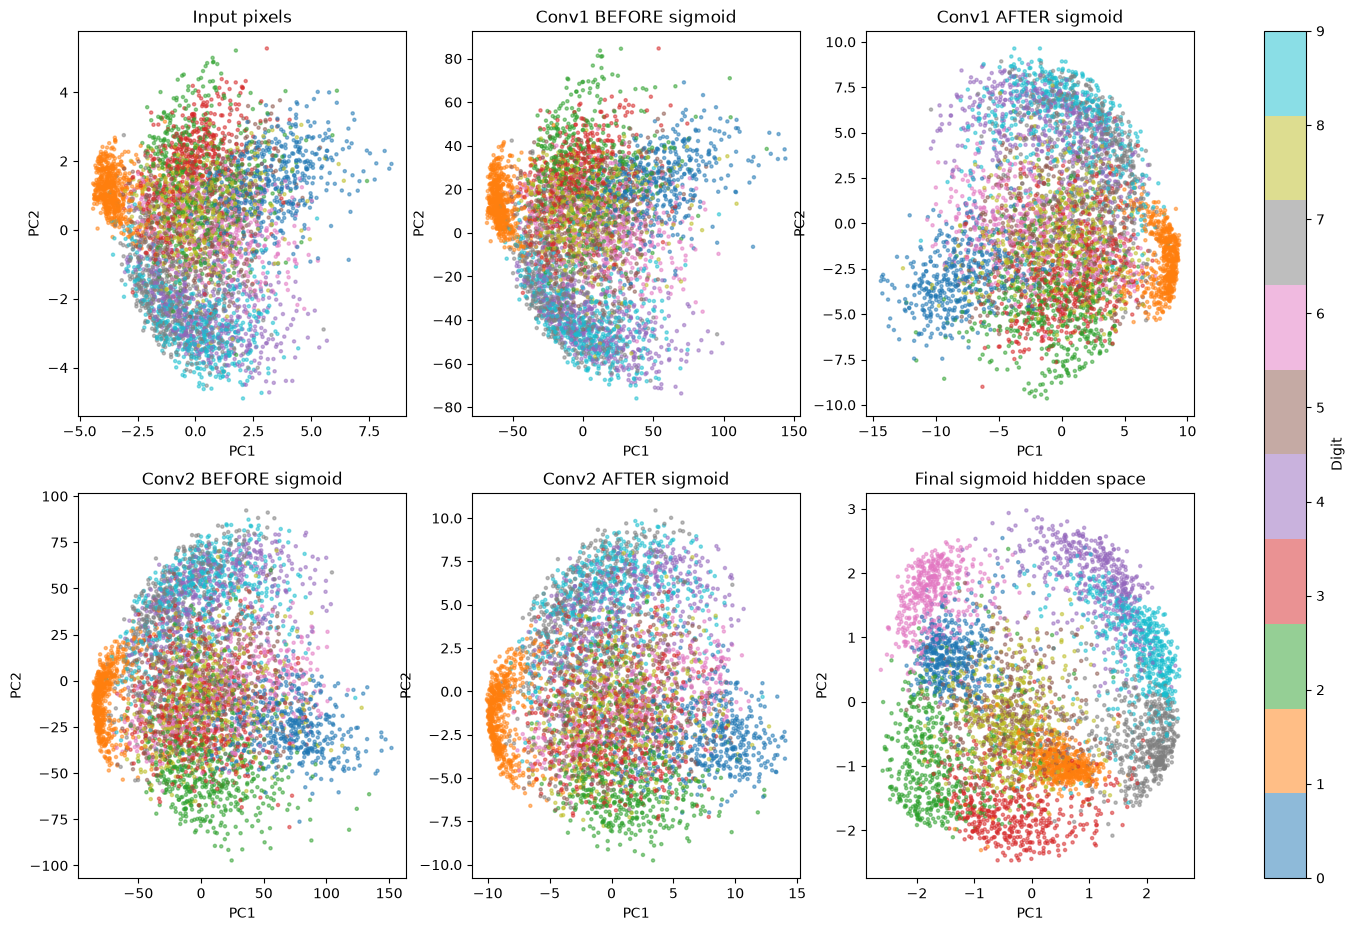

In [7]:
# ============================================================
# 12. 전체 test data의 hidden representation 추출
# ============================================================

model.eval()

labels_all = []

input_all = []

conv1_before_all = []
conv1_after_all = []

conv2_before_all = []
conv2_after_all = []

hidden_all = []


with torch.no_grad():

    count = 0

    for images, labels in test_loader:

        images = images.to(device)

        features = model(
            images,
            return_features=True
        )


        # input
        input_flat = (
            images
            .flatten(1)
            .cpu()
            .numpy()
        )


        # Conv1 before sigmoid
        c1_before = (
            features["conv1_before"]
            .flatten(1)
            .cpu()
            .numpy()
        )


        # Conv1 after sigmoid
        c1_after = (
            features["conv1_after"]
            .flatten(1)
            .cpu()
            .numpy()
        )


        # Conv2 before sigmoid
        c2_before = (
            features["conv2_before"]
            .flatten(1)
            .cpu()
            .numpy()
        )


        # Conv2 after sigmoid
        c2_after = (
            features["conv2_after"]
            .flatten(1)
            .cpu()
            .numpy()
        )


        hidden = (
            features["hidden"]
            .cpu()
            .numpy()
        )


        input_all.append(input_flat)

        conv1_before_all.append(c1_before)
        conv1_after_all.append(c1_after)

        conv2_before_all.append(c2_before)
        conv2_after_all.append(c2_after)

        hidden_all.append(hidden)

        labels_all.append(
            labels.numpy()
        )


        count += images.size(0)

        if count >= 5000:
            break


# ============================================================
# 13. concatenate
# ============================================================

input_all = np.concatenate(input_all)

conv1_before_all = np.concatenate(
    conv1_before_all
)

conv1_after_all = np.concatenate(
    conv1_after_all
)

conv2_before_all = np.concatenate(
    conv2_before_all
)

conv2_after_all = np.concatenate(
    conv2_after_all
)

hidden_all = np.concatenate(
    hidden_all
)

labels_all = np.concatenate(
    labels_all
)


N = min(
    5000,
    len(labels_all)
)


input_all = input_all[:N]

conv1_before_all = conv1_before_all[:N]
conv1_after_all = conv1_after_all[:N]

conv2_before_all = conv2_before_all[:N]
conv2_after_all = conv2_after_all[:N]

hidden_all = hidden_all[:N]

labels_all = labels_all[:N]


# ============================================================
# 14. PCA helper
# ============================================================

def to_pca_2d(features):

    pca = PCA(
        n_components=2
    )

    return pca.fit_transform(
        features
    )


# ============================================================
# 15. PCA
# ============================================================

input_2d = to_pca_2d(
    input_all
)

conv1_before_2d = to_pca_2d(
    conv1_before_all
)

conv1_after_2d = to_pca_2d(
    conv1_after_all
)

conv2_before_2d = to_pca_2d(
    conv2_before_all
)

conv2_after_2d = to_pca_2d(
    conv2_after_all
)

hidden_2d = to_pca_2d(
    hidden_all
)


# ============================================================
# 16. Hidden space 변화
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11)
)


representations = [

    (
        input_2d,
        "Input pixels"
    ),

    (
        conv1_before_2d,
        "Conv1 BEFORE sigmoid"
    ),

    (
        conv1_after_2d,
        "Conv1 AFTER sigmoid"
    ),

    (
        conv2_before_2d,
        "Conv2 BEFORE sigmoid"
    ),

    (
        conv2_after_2d,
        "Conv2 AFTER sigmoid"
    ),

    (
        hidden_2d,
        "Final sigmoid hidden space"
    )
]


for ax, (data, title) in zip(
    axes.flat,
    representations
):

    scatter = ax.scatter(

        data[:, 0],
        data[:, 1],

        c=labels_all,

        cmap="tab10",

        s=5,
        alpha=0.5
    )


    ax.set_title(title)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")


plt.colorbar(
    scatter,
    ax=axes,
    label="Digit"
)

plt.show()

In [9]:
# ============================================================
# Interactive PCA HTML
#
# 점 클릭 ->
#   - 원본 MNIST 이미지
#   - True label
#   - Prediction
#   - PCA 좌표
# 확인 가능
# ============================================================

import json
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA


# ============================================================
# 1. Hidden representation + original image 수집
# ============================================================

model.eval()

hidden_all = []
labels_all = []
predictions_all = []
images_all = []

MAX_POINTS = 3000

count = 0

with torch.no_grad():

    for images, labels in test_loader:

        images_device = images.to(device)

        features = model(
            images_device,
            return_features=True
        )

        logits = features["logits"]
        hidden = features["hidden"]

        predictions = logits.argmax(dim=1)

        hidden_all.append(
            hidden.cpu().numpy()
        )

        labels_all.append(
            labels.numpy()
        )

        predictions_all.append(
            predictions.cpu().numpy()
        )

        images_all.append(
            images.numpy()
        )

        count += len(images)

        if count >= MAX_POINTS:
            break


hidden_all = np.concatenate(hidden_all)[:MAX_POINTS]
labels_all = np.concatenate(labels_all)[:MAX_POINTS]
predictions_all = np.concatenate(predictions_all)[:MAX_POINTS]
images_all = np.concatenate(images_all)[:MAX_POINTS]


print(
    "Hidden shape:",
    hidden_all.shape
)


# ============================================================
# 2. PCA
# ============================================================

pca = PCA(
    n_components=2
)

hidden_2d = pca.fit_transform(
    hidden_all
)


print(
    "PCA explained variance:",
    pca.explained_variance_ratio_
)


# ============================================================
# 3. Plotly scatter
#
# customdata에
# index / true / prediction 저장
# ============================================================

customdata = np.column_stack([
    np.arange(len(labels_all)),
    labels_all,
    predictions_all
])


fig = go.Figure()


# 숫자별로 trace를 나눔
# -> legend에서 숫자 ON/OFF 가능
for digit in range(10):

    mask = (
        labels_all == digit
    )

    fig.add_trace(

        go.Scattergl(

            x=hidden_2d[mask, 0],

            y=hidden_2d[mask, 1],

            mode="markers",

            name=str(digit),

            marker=dict(
                size=6,
                opacity=0.7
            ),

            customdata=customdata[mask],

            hovertemplate=(
                "<b>Digit %{customdata[1]}</b>"
                "<br>Prediction: %{customdata[2]}"
                "<br>PC1: %{x:.3f}"
                "<br>PC2: %{y:.3f}"
                "<extra></extra>"
            )
        )
    )


# ============================================================
# 4. Layout
# ============================================================

fig.update_layout(

    title=(
        "MNIST CNN Hidden Space "
        "- Sigmoid + PCA"
    ),

    xaxis_title="PC1",

    yaxis_title="PC2",

    height=750,

    hovermode="closest",

    legend_title="True digit"
)


# ============================================================
# 5. MNIST 이미지를 JS로 넘길 데이터
#
# 28x28 float -> 0~255 integer
# ============================================================

images_uint8 = (
    images_all[:, 0] * 255
).astype(np.uint8)


# Python list로 변환
# JS에서 canvas에 바로 그림
images_json = json.dumps(
    images_uint8.tolist()
)


# ============================================================
# 6. HTML용 JavaScript
# ============================================================

post_script = f"""

// ===========================================================
// MNIST image data
// ===========================================================

const mnistImages = {images_json};


// ===========================================================
// 오른쪽 정보 패널 생성
// ===========================================================

const plotDiv = document.getElementById('{{plot_id}}');

const parent = plotDiv.parentElement;


// 전체 flex layout
const wrapper = document.createElement("div");

wrapper.style.display = "flex";
wrapper.style.gap = "20px";
wrapper.style.alignItems = "flex-start";


// 기존 plot 위치 변경
parent.insertBefore(
    wrapper,
    plotDiv
);

wrapper.appendChild(
    plotDiv
);


// ===========================================================
// Side panel
// ===========================================================

const panel = document.createElement("div");

panel.style.width = "260px";
panel.style.padding = "20px";
panel.style.border = "1px solid #ccc";
panel.style.borderRadius = "10px";
panel.style.marginTop = "80px";

panel.innerHTML = `

    <h2>Selected MNIST</h2>

    <canvas
        id="mnistCanvas"
        width="280"
        height="280"
        style="
            width: 220px;
            height: 220px;
            image-rendering: pixelated;
            background: black;
            border: 1px solid #888;
        "
    ></canvas>

    <div
        id="mnistInfo"
        style="
            margin-top: 15px;
            font-family: monospace;
            font-size: 16px;
        "
    >

        Click a point.

    </div>
`;

wrapper.appendChild(
    panel
);


// ===========================================================
// Canvas
// ===========================================================

const canvas = panel.querySelector(
    "#mnistCanvas"
);

const ctx = canvas.getContext(
    "2d"
);


ctx.imageSmoothingEnabled = false;


// ===========================================================
// Draw MNIST
// ===========================================================

function drawMNIST(index) {{

    const pixels = mnistImages[index];

    const imageData = ctx.createImageData(
        28,
        28
    );


    for (
        let y = 0;
        y < 28;
        y++
    ) {{

        for (
            let x = 0;
            x < 28;
            x++
        ) {{

            const value =
                pixels[y][x];

            const p =
                (y * 28 + x) * 4;


            imageData.data[p] = value;
            imageData.data[p + 1] = value;
            imageData.data[p + 2] = value;
            imageData.data[p + 3] = 255;
        }}
    }}


    // 임시 작은 canvas
    const tempCanvas =
        document.createElement(
            "canvas"
        );

    tempCanvas.width = 28;
    tempCanvas.height = 28;


    const tempCtx =
        tempCanvas.getContext(
            "2d"
        );

    tempCtx.putImageData(
        imageData,
        0,
        0
    );


    ctx.clearRect(
        0,
        0,
        canvas.width,
        canvas.height
    );


    ctx.drawImage(
        tempCanvas,
        0,
        0,
        28,
        28,
        0,
        0,
        canvas.width,
        canvas.height
    );
}}


// ===========================================================
// Plot click
// ===========================================================

plotDiv.on(
    "plotly_click",

    function(data) {{

        const point =
            data.points[0];

        const custom =
            point.customdata;


        const index =
            parseInt(custom[0]);

        const trueLabel =
            parseInt(custom[1]);

        const prediction =
            parseInt(custom[2]);


        drawMNIST(index);


        const info =
            panel.querySelector(
                "#mnistInfo"
            );


        info.innerHTML = `

            <b>Dataset index</b>: ${{index}}

            <br><br>

            <b>True label</b>:
            ${{trueLabel}}

            <br>

            <b>Prediction</b>:
            ${{prediction}}

            <br><br>

            <b>PC1</b>:
            ${{point.x.toFixed(4)}}

            <br>

            <b>PC2</b>:
            ${{point.y.toFixed(4)}}

        `;


        // 맞으면 / 틀리면 텍스트 표시
        if (
            trueLabel === prediction
        ) {{

            info.innerHTML +=
                "<br><br>✓ Correct";

        }}

        else {{

            info.innerHTML +=
                "<br><br>✗ Wrong";

        }}
    }}
);

"""


# ============================================================
# 7. HTML export
# ============================================================

fig.write_html(

    "mnist_hidden_pca.html",

    include_plotlyjs=True,

    full_html=True,

    post_script=post_script
)


print(
    "Saved: mnist_hidden_pca.html"
)

Hidden shape: (3000, 64)
PCA explained variance: [0.22855666 0.18173422]
Saved: mnist_hidden_pca.html


Original shape
(60000, 784)

After SVD
(15000, 50)


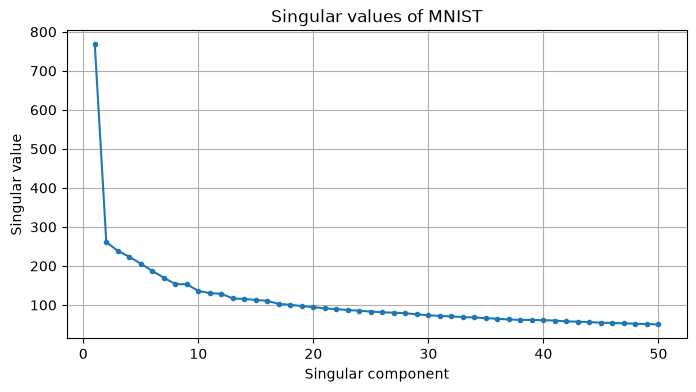

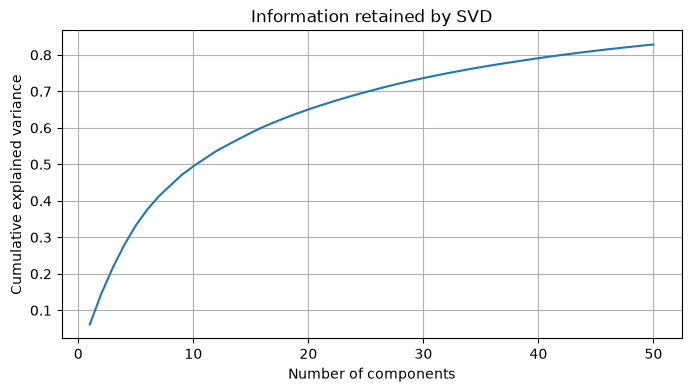

Training SVM...
Accuracy: 96.17%


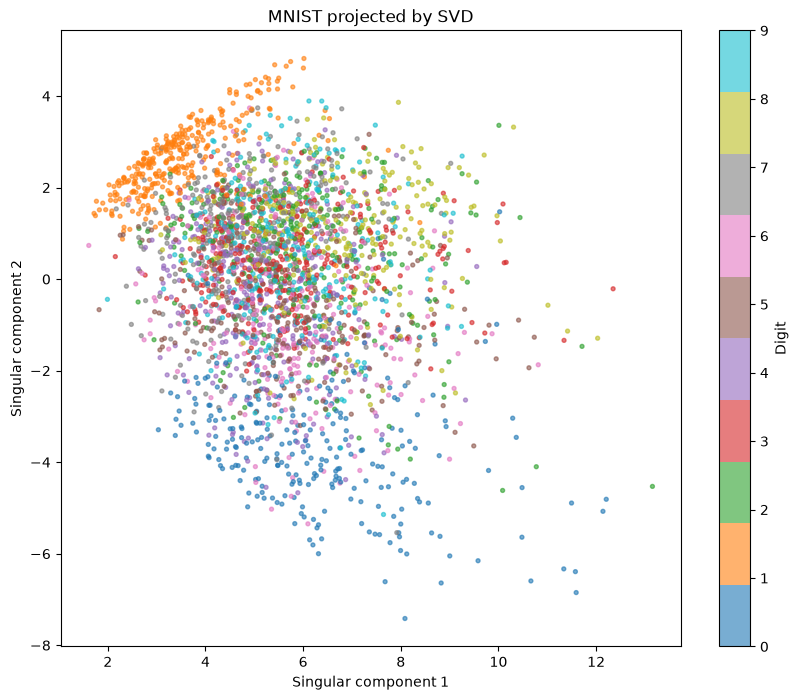

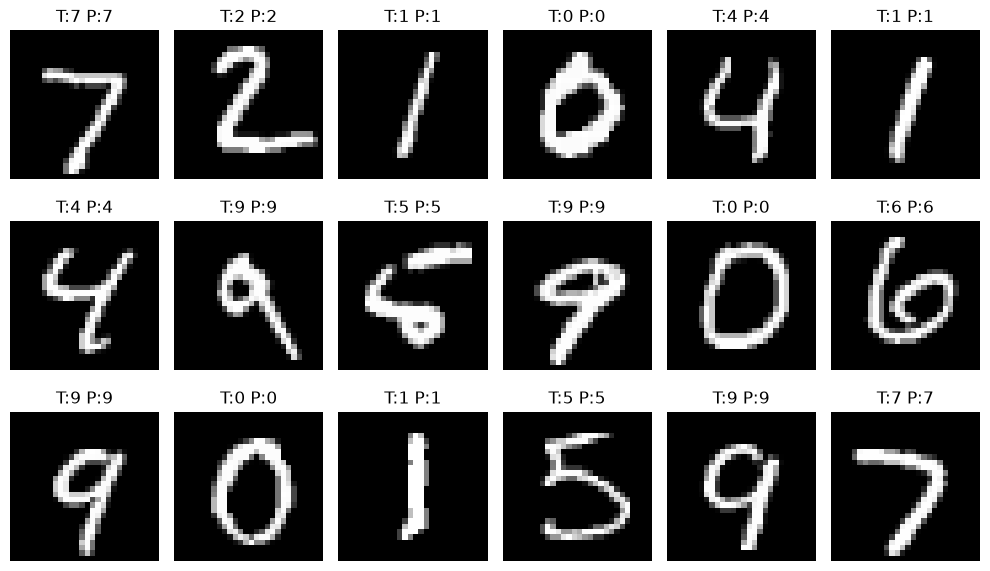

In [10]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets, transforms

from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


# ============================================================
# 1. MNIST load
# ============================================================

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transforms.ToTensor()
)


# ============================================================
# 2. Tensor -> numpy
#
# 28 x 28 image
#     ↓
# 784 dimensional vector
# ============================================================

X_train = train_dataset.data.numpy().astype(np.float32)
y_train = train_dataset.targets.numpy()

X_test = test_dataset.data.numpy().astype(np.float32)
y_test = test_dataset.targets.numpy()


X_train = X_train.reshape(
    len(X_train),
    -1
)

X_test = X_test.reshape(
    len(X_test),
    -1
)


# normalize
X_train /= 255.0
X_test /= 255.0


print("Original shape")
print(X_train.shape)

# (60000, 784)


# ============================================================
# 3. 일부 데이터만 사용
#
# SVM은 전체 60,000개 RBF로 돌리면 좀 무거울 수 있음
# ============================================================

N_TRAIN = 15000
N_TEST = 3000

X_train_small = X_train[:N_TRAIN]
y_train_small = y_train[:N_TRAIN]

X_test_small = X_test[:N_TEST]
y_test_small = y_test[:N_TEST]


# ============================================================
# 4. SVD
#
# X ≈ U_k Sigma_k V_k^T
#
# 784 dimensions -> 50 dimensions
# ============================================================

k = 50

svd = TruncatedSVD(
    n_components=k,
    random_state=42
)

X_train_svd = svd.fit_transform(
    X_train_small
)

X_test_svd = svd.transform(
    X_test_small
)


print()
print("After SVD")
print(X_train_svd.shape)

# (15000, 50)


# ============================================================
# 5. Singular value 확인
# ============================================================

singular_values = svd.singular_values_

plt.figure(figsize=(8, 4))

plt.plot(
    np.arange(1, k + 1),
    singular_values,
    marker="."
)

plt.xlabel("Singular component")
plt.ylabel("Singular value")

plt.title(
    "Singular values of MNIST"
)

plt.grid()

plt.show()


# ============================================================
# 6. 누적 설명 비율
# ============================================================

cumulative_variance = np.cumsum(
    svd.explained_variance_ratio_
)


plt.figure(figsize=(8, 4))

plt.plot(
    np.arange(1, k + 1),
    cumulative_variance
)

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")

plt.title(
    "Information retained by SVD"
)

plt.grid()

plt.show()


# ============================================================
# 7. Scaling
#
# SVM에서는 feature scale 맞춰주는 것이 좋음
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_svd
)

X_test_scaled = scaler.transform(
    X_test_svd
)


# ============================================================
# 8. SVM
#
# RBF kernel
# ============================================================

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

print("Training SVM...")

svm.fit(
    X_train_scaled,
    y_train_small
)


# ============================================================
# 9. Prediction
# ============================================================

pred = svm.predict(
    X_test_scaled
)

accuracy = accuracy_score(
    y_test_small,
    pred
)


print(
    f"Accuracy: {accuracy * 100:.2f}%"
)


# ============================================================
# 10. SVD 2D visualization
#
# SVD feature 중 처음 두 축만 사용
# ============================================================

X_2d = X_test_svd[:, :2]


plt.figure(
    figsize=(10, 8)
)

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_test_small,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.xlabel(
    "Singular component 1"
)

plt.ylabel(
    "Singular component 2"
)

plt.title(
    "MNIST projected by SVD"
)

plt.colorbar(
    scatter,
    label="Digit"
)

plt.show()


# ============================================================
# 11. Prediction sample
# ============================================================

fig, axes = plt.subplots(
    3,
    6,
    figsize=(10, 6)
)


for i, ax in enumerate(
    axes.flat
):

    image = X_test_small[i].reshape(
        28,
        28
    )

    ax.imshow(
        image,
        cmap="gray"
    )

    ax.set_title(
        f"T:{y_test_small[i]} "
        f"P:{pred[i]}"
    )

    ax.axis("off")


plt.tight_layout()

plt.show()

X : (60000, 784)
Vᵀ: (50, 784)
Z : (60000, 50)


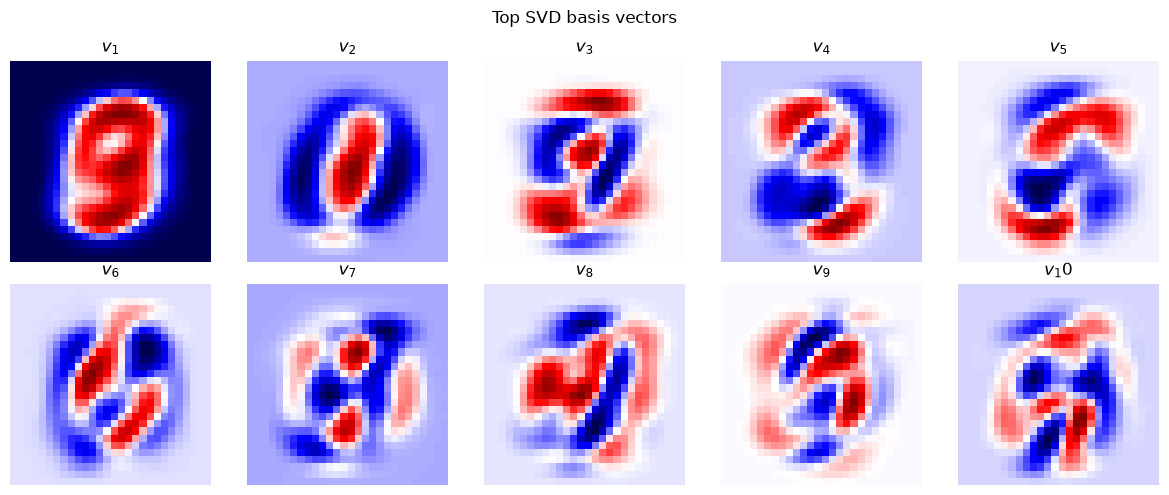

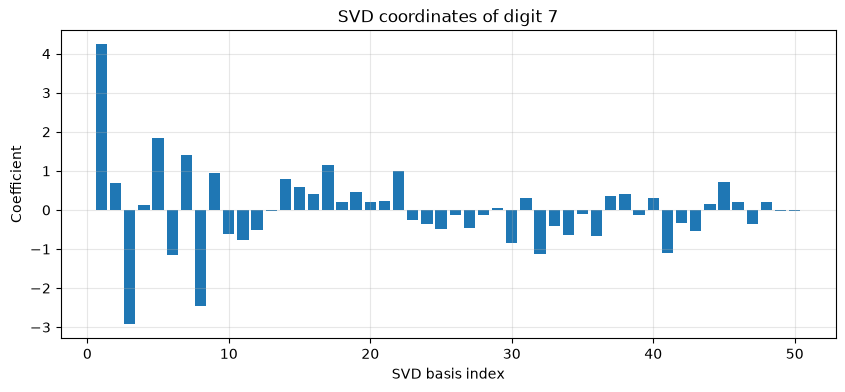

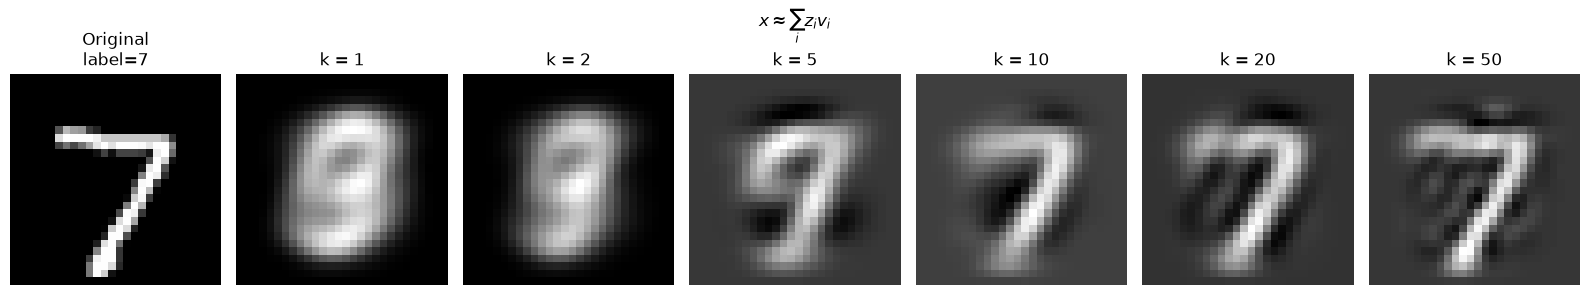

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from torchvision import datasets
from sklearn.decomposition import TruncatedSVD
from sklearn.svm import SVC


# ============================================================
# 1. MNIST
# ============================================================

train = datasets.MNIST(
    "./data",
    train=True,
    download=True
)

test = datasets.MNIST(
    "./data",
    train=False,
    download=True
)

X_train = train.data.numpy().astype(np.float32) / 255.0
y_train = train.targets.numpy()

X_test = test.data.numpy().astype(np.float32) / 255.0
y_test = test.targets.numpy()


# 이미지 -> vector
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)


# ============================================================
# 2. SVD
#
# X ≈ U Σ V^T
#
# 각 이미지:
#
# x (784D)
#     ↓
# x V_k
#     ↓
# z (k-D)
#
# ============================================================

k = 50

svd = TruncatedSVD(
    n_components=k,
    random_state=42
)

Z_train = svd.fit_transform(X_train)
Z_test = svd.transform(X_test)


print("X :", X_train.shape)
print("Vᵀ:", svd.components_.shape)
print("Z :", Z_train.shape)


# ============================================================
# 3. SVD basis image 보기
#
# V의 각 row = 784D 방향
#
# 784 -> 28x28 로 reshape
# ============================================================

fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for i, ax in enumerate(axes.flat):

    basis = svd.components_[i].reshape(
        28,
        28
    )

    ax.imshow(
        basis,
        cmap="seismic"
    )

    ax.set_title(
        f"$v_{i+1}$"
    )

    ax.axis("off")


plt.suptitle(
    "Top SVD basis vectors"
)

plt.tight_layout()
plt.show()


# ============================================================
# 4. 이미지 하나 선택
# ============================================================

index = 0

x = X_test[index]

label = y_test[index]

z = Z_test[index]


# ============================================================
# 5. 각 SVD component의 coefficient
#
# z_i = <x, v_i>
#
# 즉 이미지가 각 basis 방향을
# 얼마나 가지고 있는지
# ============================================================

plt.figure(
    figsize=(10, 4)
)

plt.bar(
    np.arange(1, k + 1),
    z
)

plt.xlabel(
    "SVD basis index"
)

plt.ylabel(
    "Coefficient"
)

plt.title(
    f"SVD coordinates of digit {label}"
)

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# 6. Original vs Reconstruction
#
# x ≈ Σ z_i v_i
# ============================================================

component_counts = [
    1,
    2,
    5,
    10,
    20,
    50
]


fig, axes = plt.subplots(
    1,
    len(component_counts) + 1,
    figsize=(16, 3)
)


# Original
axes[0].imshow(
    x.reshape(28, 28),
    cmap="gray"
)

axes[0].set_title(
    f"Original\nlabel={label}"
)

axes[0].axis("off")


# reconstruction
for ax, n_components in zip(
    axes[1:],
    component_counts
):

    # z[:n] @ V[:n]
    reconstruction = (
        z[:n_components]
        @ svd.components_[:n_components]
    )

    ax.imshow(
        reconstruction.reshape(28, 28),
        cmap="gray"
    )

    ax.set_title(
        f"k = {n_components}"
    )

    ax.axis("off")


plt.suptitle(
    r"$x \approx \sum_i z_i v_i$"
)

plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torchvision import datasets
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import TruncatedSVD


# ============================================================
# 1. MNIST
# ============================================================

train_data = datasets.MNIST(
    "./data",
    train=True,
    download=True
)

test_data = datasets.MNIST(
    "./data",
    train=False,
    download=True
)


X_train = (
    train_data.data.numpy()
    .astype(np.float32)
    / 255.0
)

X_test = (
    test_data.data.numpy()
    .astype(np.float32)
    / 255.0
)

y_train = train_data.targets.numpy()
y_test = test_data.targets.numpy()


print("Original:")
print(X_train.shape)
# (60000, 28, 28)


# ============================================================
# 2. Flatten
# ============================================================

X_train_flat = X_train.reshape(-1, 784)
X_test_flat = X_test.reshape(-1, 784)


print("Flatten:")
print(X_train_flat.shape)
# (60000, 784)


# ============================================================
# 3. SVD
#
# 784D -> kD
# ============================================================

K = 50

svd = TruncatedSVD(
    n_components=K,
    random_state=42
)

Z_train = svd.fit_transform(
    X_train_flat
)

Z_test = svd.transform(
    X_test_flat
)


print("SVD space:")
print(Z_train.shape)
# (60000, 50)


# ============================================================
# 4. Reconstruction
#
# Z V^T
#
# (60000 x 50)
#      @
# (50 x 784)
#
# ->
# (60000 x 784)
# ============================================================

X_train_recon = svd.inverse_transform(
    Z_train
)

X_test_recon = svd.inverse_transform(
    Z_test
)


# pixel 범위 제한
X_train_recon = np.clip(
    X_train_recon,
    0,
    1
)

X_test_recon = np.clip(
    X_test_recon,
    0,
    1
)


# 다시 이미지 모양으로
X_train_recon = X_train_recon.reshape(
    -1,
    28,
    28
)

X_test_recon = X_test_recon.reshape(
    -1,
    28,
    28
)


print("Reconstructed:")
print(X_train_recon.shape)
# (60000, 28, 28)

Original:
(60000, 28, 28)
Flatten:
(60000, 784)
SVD space:
(60000, 50)
Reconstructed:
(60000, 28, 28)


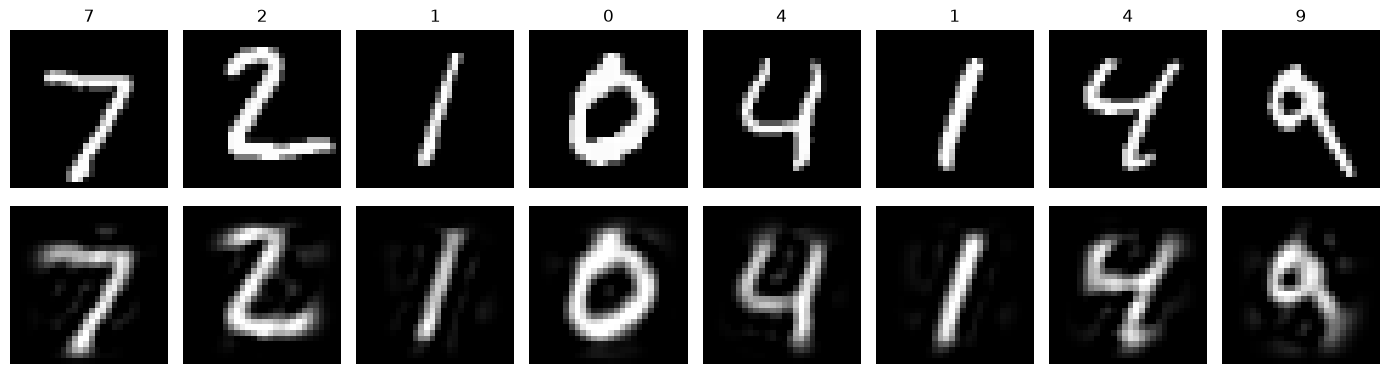

In [14]:
# ============================================================
# 5. Original vs SVD reconstructed
# ============================================================

fig, axes = plt.subplots(
    2,
    8,
    figsize=(14, 4)
)

for i in range(8):

    axes[0, i].imshow(
        X_test[i],
        cmap="gray"
    )

    axes[0, i].set_title(
        f"{y_test[i]}"
    )

    axes[0, i].axis("off")


    axes[1, i].imshow(
        X_test_recon[i],
        cmap="gray"
    )

    axes[1, i].axis("off")


axes[0, 0].set_ylabel(
    "Original"
)

axes[1, 0].set_ylabel(
    f"SVD k={K}"
)

plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# 6. Dataset
# ============================================================

class SVDDataset(Dataset):

    def __init__(
        self,
        images,
        labels
    ):

        self.images = torch.tensor(
            images,
            dtype=torch.float32
        ).unsqueeze(1)

        self.labels = torch.tensor(
            labels,
            dtype=torch.long
        )


    def __len__(self):
        return len(self.labels)


    def __getitem__(self, idx):

        return (
            self.images[idx],
            self.labels[idx]
        )


train_dataset = SVDDataset(
    X_train_recon,
    y_train
)

test_dataset = SVDDataset(
    X_test_recon,
    y_test
)


train_loader = DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

In [16]:
# ============================================================
# 7. CNN
# ============================================================

class CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            16,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(2)

        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(
            32 * 7 * 7,
            64
        )

        self.fc2 = nn.Linear(
            64,
            10
        )


    def forward(self, x):

        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)

        x = x.flatten(1)

        x = self.relu(
            self.fc1(x)
        )

        return self.fc2(x)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

model = CNN().to(device)

In [17]:
# ============================================================
# 8. Train
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)


EPOCHS = 5


for epoch in range(EPOCHS):

    model.train()

    total_loss = 0


    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    print(
        f"Epoch {epoch+1}/{EPOCHS} "
        f"loss={total_loss / len(train_loader):.4f}"
    )

Epoch 1/5 loss=0.5466
Epoch 2/5 loss=0.1528
Epoch 3/5 loss=0.1051
Epoch 4/5 loss=0.0858
Epoch 5/5 loss=0.0745


In [20]:
# ============================================================
# 9. Test
# ============================================================

model.eval()

correct = 0
total = 0


with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)

        pred = logits.argmax(
            dim=1
        )

        correct += (
            pred == labels
        ).sum().item()

        total += len(labels)


accuracy = correct / total

print(
    f"Test accuracy: "
    f"{accuracy * 100:.2f}%"
)

Test accuracy: 98.15%


In [ ]:
class CNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            16,
            3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            3,
            padding=1
        )

        self.pool = nn.MaxPool2d(2)

        # ReLU -> Sigmoid
        self.sigmoid = nn.Sigmoid()

        self.fc1 = nn.Linear(
            32 * 7 * 7,
            64
        )

        self.fc2 = nn.Linear(
            64,
            10
        )


    def forward(
        self,
        x,
        return_features=False
    ):

        # ====================================================
        # 28 x 28
        # (B, 1, 28, 28)
        # ->
        # (B, 16, 28, 28)
        # ====================================================

        conv1 = self.conv1(x)

        sigmoid1 = self.sigmoid(conv1)

        pool1 = self.pool(sigmoid1)


        # ====================================================
        # 14 x 14
        # (B, 16, 14, 14)
        # ->
        # (B, 32, 14, 14)
        # ====================================================

        conv2 = self.conv2(pool1)

        sigmoid2 = self.sigmoid(conv2)

        pool2 = self.pool(sigmoid2)


        # ====================================================
        # (B, 32, 7, 7)
        # ->
        # (B, 1568)
        # ====================================================

        flat = pool2.flatten(1)


        # ====================================================
        # 1568 -> 64
        # ====================================================

        fc1 = self.fc1(flat)

        hidden = self.sigmoid(fc1)


        # ====================================================
        # 64 -> 10
        #
        # 여기에는 sigmoid 넣지 않음.
        # CrossEntropyLoss가 raw logits를 사용.
        # ====================================================

        logits = self.fc2(hidden)


        if return_features:

            return {
                "conv1": conv1,
                "sigmoid1": sigmoid1,
                "pool1": pool1,

                "conv2": conv2,
                "sigmoid2": sigmoid2,
                "pool2": pool2,

                "flat": flat,
                "fc1": fc1,
                "hidden": hidden,

                "logits": logits
            }

        return logits

True: 7
Prediction: 7


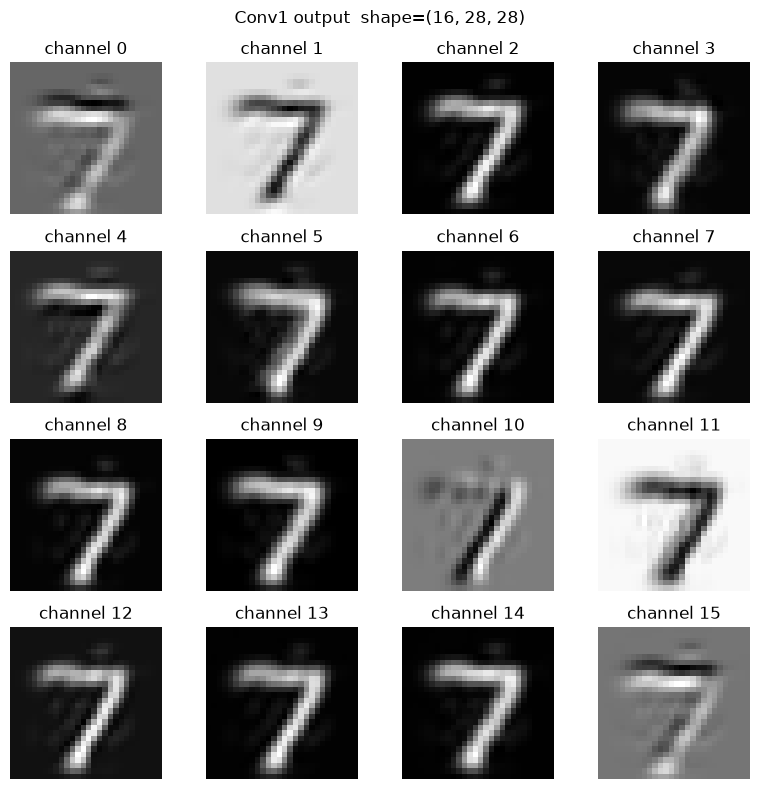

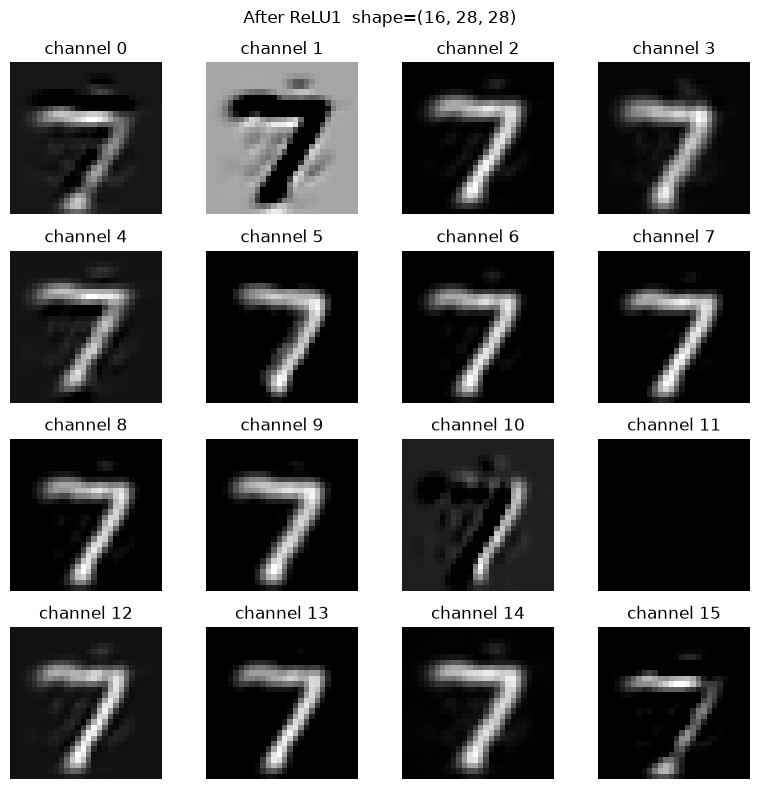

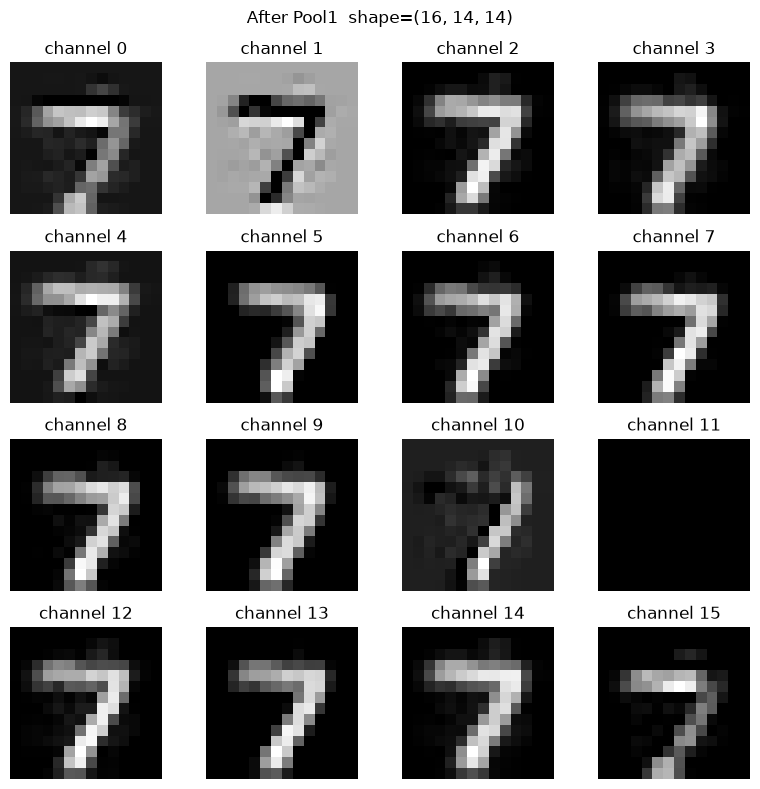

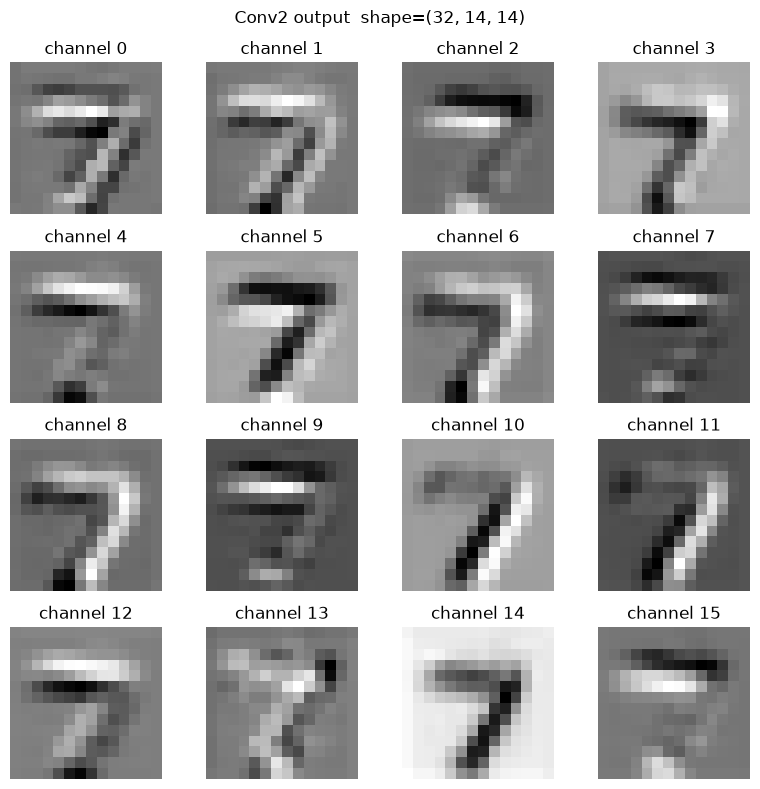

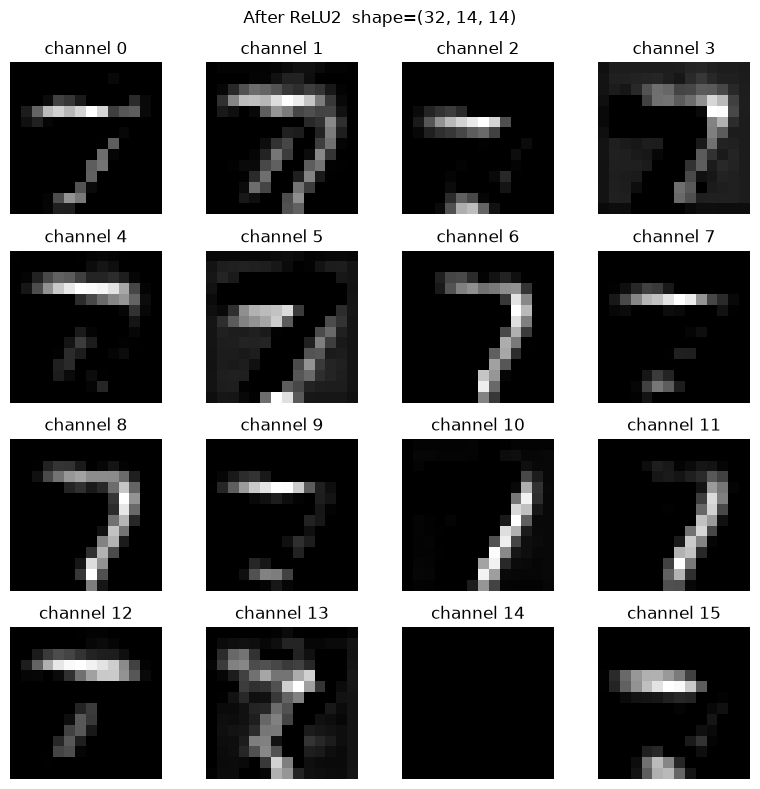

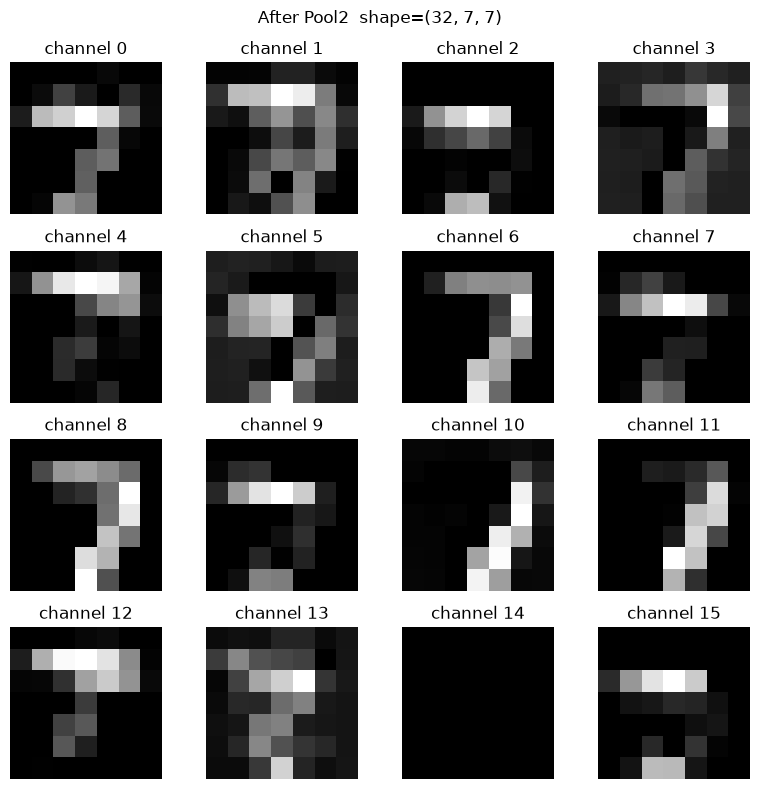

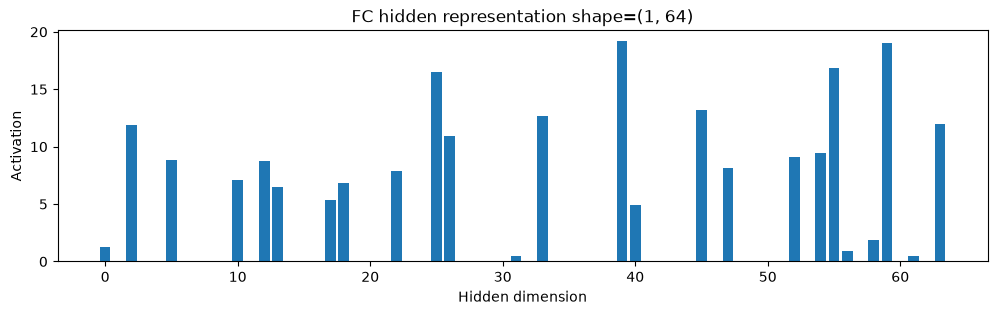

In [28]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA


# ============================================================
# 1. CNN forward hook용 feature 저장
# ============================================================

features = {}


def save_feature(name):

    def hook(module, input, output):
        features[name] = output.detach()

    return hook


# 모델 구조가 아래 이름을 가진다고 가정
#
# model.conv1
# model.relu
# model.pool
# model.conv2
# model.fc1
#
# ReLU/Pool을 공유해서 사용했다면 forward 자체를 수정하는 게 더 좋음.
#
# 여기서는 conv1, conv2, fc1 hook만 사용하고
# activation은 직접 계산해서 시각화함.

hooks = []

hooks.append(
    model.conv1.register_forward_hook(
        save_feature("conv1")
    )
)

hooks.append(
    model.conv2.register_forward_hook(
        save_feature("conv2")
    )
)

hooks.append(
    model.fc1.register_forward_hook(
        save_feature("fc1")
    )
)


# ============================================================
# 2. 이미지 하나 선택
# ============================================================

index = 0

image = torch.tensor(
    X_test_recon[index],
    dtype=torch.float32
)

image = (
    image
    .unsqueeze(0)
    .unsqueeze(0)
    .to(device)
)


model.eval()

with torch.no_grad():
    logits = model(image)


prediction = logits.argmax(1).item()

print("True:", y_test[index])
print("Prediction:", prediction)


# ============================================================
# 3. Feature map 시각화 함수
# ============================================================

def show_feature_maps(
    tensor,
    title,
    max_channels=16
):

    x = (
        tensor[0]
        .detach()
        .cpu()
        .numpy()
    )

    # FC layer면 feature map이 아니므로 제외
    if x.ndim != 3:
        print(
            title,
            "shape:",
            x.shape
        )
        return


    n = min(
        max_channels,
        x.shape[0]
    )

    cols = 4

    rows = int(
        np.ceil(n / cols)
    )


    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(8, 2 * rows)
    )

    axes = np.array(
        axes
    ).reshape(-1)


    for i in range(n):

        axes[i].imshow(
            x[i],
            cmap="gray"
        )

        axes[i].set_title(
            f"channel {i}"
        )

        axes[i].axis("off")


    for i in range(
        n,
        len(axes)
    ):

        axes[i].axis("off")


    plt.suptitle(
        f"{title}  shape={x.shape}"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 4. Conv1 feature
# ============================================================

conv1 = features["conv1"]

relu1 = torch.relu(conv1)

pool1 = torch.nn.functional.max_pool2d(
    relu1,
    2
)


show_feature_maps(
    conv1,
    "Conv1 output"
)

show_feature_maps(
    relu1,
    "After ReLU1"
)

show_feature_maps(
    pool1,
    "After Pool1"
)


# ============================================================
# 5. Conv2 feature
# ============================================================

conv2 = features["conv2"]

relu2 = torch.relu(conv2)

pool2 = torch.nn.functional.max_pool2d(
    relu2,
    2
)


show_feature_maps(
    conv2,
    "Conv2 output",
    max_channels=16
)

show_feature_maps(
    relu2,
    "After ReLU2",
    max_channels=16
)

show_feature_maps(
    pool2,
    "After Pool2",
    max_channels=16
)


# ============================================================
# 6. FC hidden vector
# ============================================================

fc1 = features["fc1"]

hidden = torch.relu(fc1)

plt.figure(
    figsize=(12, 3)
)

plt.bar(
    np.arange(hidden.shape[1]),
    hidden[0].cpu().numpy()
)

plt.xlabel("Hidden dimension")
plt.ylabel("Activation")

plt.title(
    f"FC hidden representation "
    f"shape={tuple(hidden.shape)}"
)

plt.show()


# ============================================================
# 7. hook 제거
# ============================================================

for h in hooks:
    h.remove()

Input : (3000, 784)
Conv1 : (3000, 12544)
Pool1 : (3000, 3136)
Conv2 : (3000, 6272)
Pool2 : (3000, 1568)
Hidden: (3000, 64)


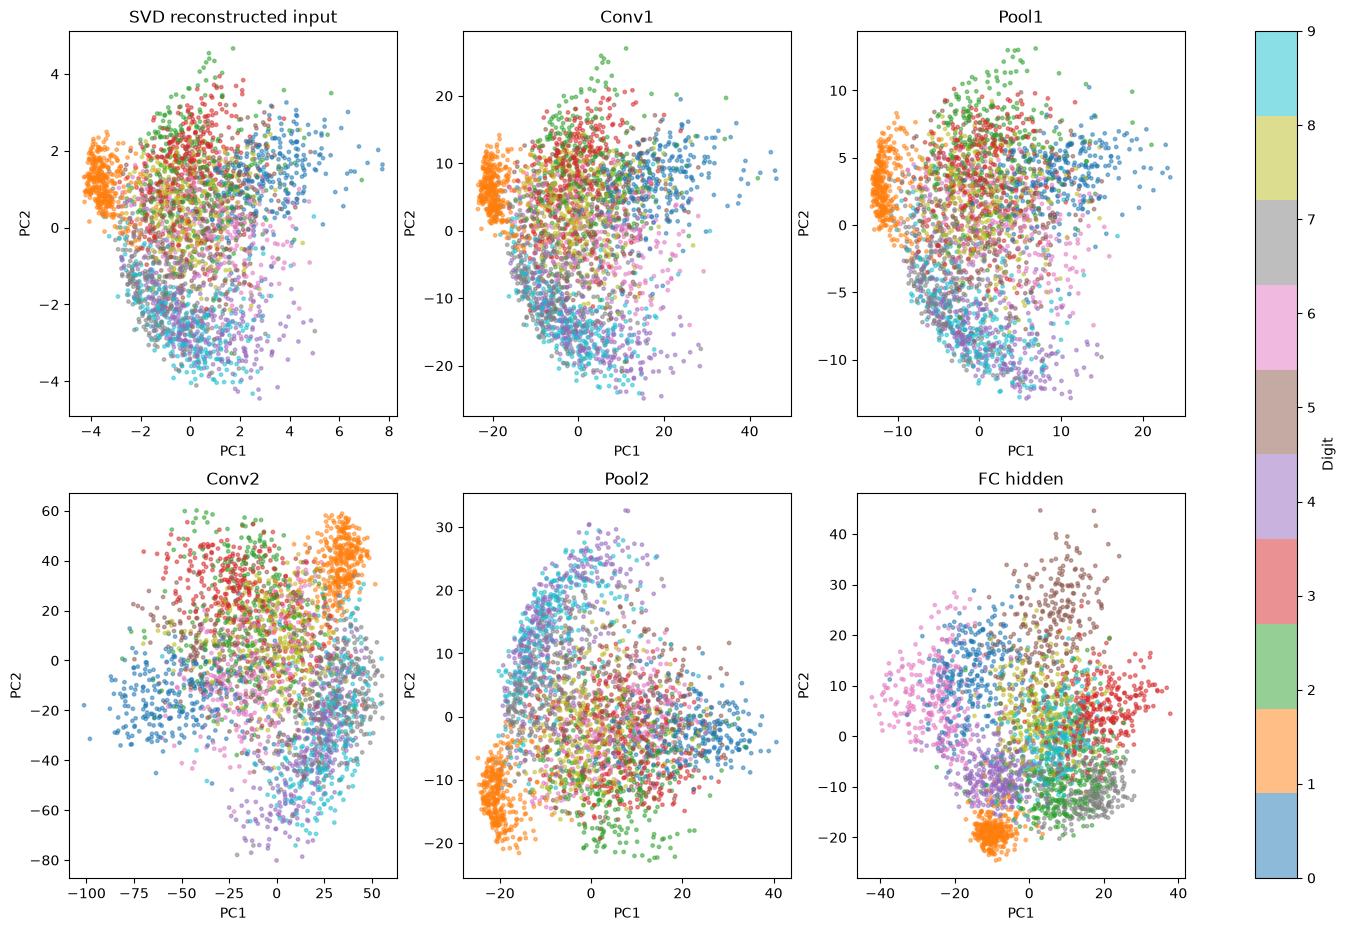

In [29]:
# ============================================================
# CNN layer representations -> PCA
# ============================================================

from sklearn.decomposition import PCA


# ============================================================
# 1. 다시 hook
# ============================================================

features = {}


def save_feature(name):

    def hook(module, input, output):
        features[name] = output.detach()

    return hook


h1 = model.conv1.register_forward_hook(
    save_feature("conv1")
)

h2 = model.conv2.register_forward_hook(
    save_feature("conv2")
)

h3 = model.fc1.register_forward_hook(
    save_feature("fc1")
)


# ============================================================
# 2. 여러 이미지의 feature 수집
# ============================================================

N = 3000
BATCH = 256


input_features = []
conv1_features = []
pool1_features = []

conv2_features = []
pool2_features = []

hidden_features = []

labels_all = []


model.eval()


with torch.no_grad():

    for start in range(
        0,
        N,
        BATCH
    ):

        end = min(
            start + BATCH,
            N
        )


        images = torch.tensor(
            X_test_recon[start:end],
            dtype=torch.float32
        )

        images = (
            images
            .unsqueeze(1)
            .to(device)
        )


        logits = model(images)


        # -----------------------------------------
        # Input
        # -----------------------------------------

        input_flat = images.flatten(1)


        # -----------------------------------------
        # Conv1
        # -----------------------------------------

        conv1 = features["conv1"]

        relu1 = torch.relu(conv1)

        pool1 = torch.nn.functional.max_pool2d(
            relu1,
            2
        )


        # -----------------------------------------
        # Conv2
        # -----------------------------------------

        conv2 = features["conv2"]

        relu2 = torch.relu(conv2)

        pool2 = torch.nn.functional.max_pool2d(
            relu2,
            2
        )


        # -----------------------------------------
        # FC hidden
        # -----------------------------------------

        hidden = torch.relu(
            features["fc1"]
        )


        input_features.append(
            input_flat.cpu().numpy()
        )

        conv1_features.append(
            conv1.flatten(1).cpu().numpy()
        )

        pool1_features.append(
            pool1.flatten(1).cpu().numpy()
        )

        conv2_features.append(
            conv2.flatten(1).cpu().numpy()
        )

        pool2_features.append(
            pool2.flatten(1).cpu().numpy()
        )

        hidden_features.append(
            hidden.cpu().numpy()
        )


        labels_all.append(
            y_test[start:end]
        )


# ============================================================
# 3. concat
# ============================================================

input_features = np.concatenate(
    input_features
)

conv1_features = np.concatenate(
    conv1_features
)

pool1_features = np.concatenate(
    pool1_features
)

conv2_features = np.concatenate(
    conv2_features
)

pool2_features = np.concatenate(
    pool2_features
)

hidden_features = np.concatenate(
    hidden_features
)

labels_all = np.concatenate(
    labels_all
)


# ============================================================
# 4. Shape 출력
# ============================================================

print(
    "Input :",
    input_features.shape
)

print(
    "Conv1 :",
    conv1_features.shape
)

print(
    "Pool1 :",
    pool1_features.shape
)

print(
    "Conv2 :",
    conv2_features.shape
)

print(
    "Pool2 :",
    pool2_features.shape
)

print(
    "Hidden:",
    hidden_features.shape
)


# ============================================================
# 5. PCA helper
# ============================================================

def pca2(x):

    return PCA(
        n_components=2
    ).fit_transform(x)


# ============================================================
# 6. PCA
# ============================================================

input_2d = pca2(
    input_features
)

conv1_2d = pca2(
    conv1_features
)

pool1_2d = pca2(
    pool1_features
)

conv2_2d = pca2(
    conv2_features
)

pool2_2d = pca2(
    pool2_features
)

hidden_2d = pca2(
    hidden_features
)


# ============================================================
# 7. Plot
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11)
)


data_list = [

    (
        input_2d,
        "SVD reconstructed input"
    ),

    (
        conv1_2d,
        "Conv1"
    ),

    (
        pool1_2d,
        "Pool1"
    ),

    (
        conv2_2d,
        "Conv2"
    ),

    (
        pool2_2d,
        "Pool2"
    ),

    (
        hidden_2d,
        "FC hidden"
    )
]


for ax, (data, title) in zip(
    axes.flat,
    data_list
):

    scatter = ax.scatter(
        data[:, 0],
        data[:, 1],
        c=labels_all,
        cmap="tab10",
        s=6,
        alpha=0.5
    )

    ax.set_title(title)

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")


plt.colorbar(
    scatter,
    ax=axes,
    label="Digit"
)

plt.show()


# ============================================================
# 8. hooks 제거
# ============================================================

h1.remove()
h2.remove()
h3.remove()